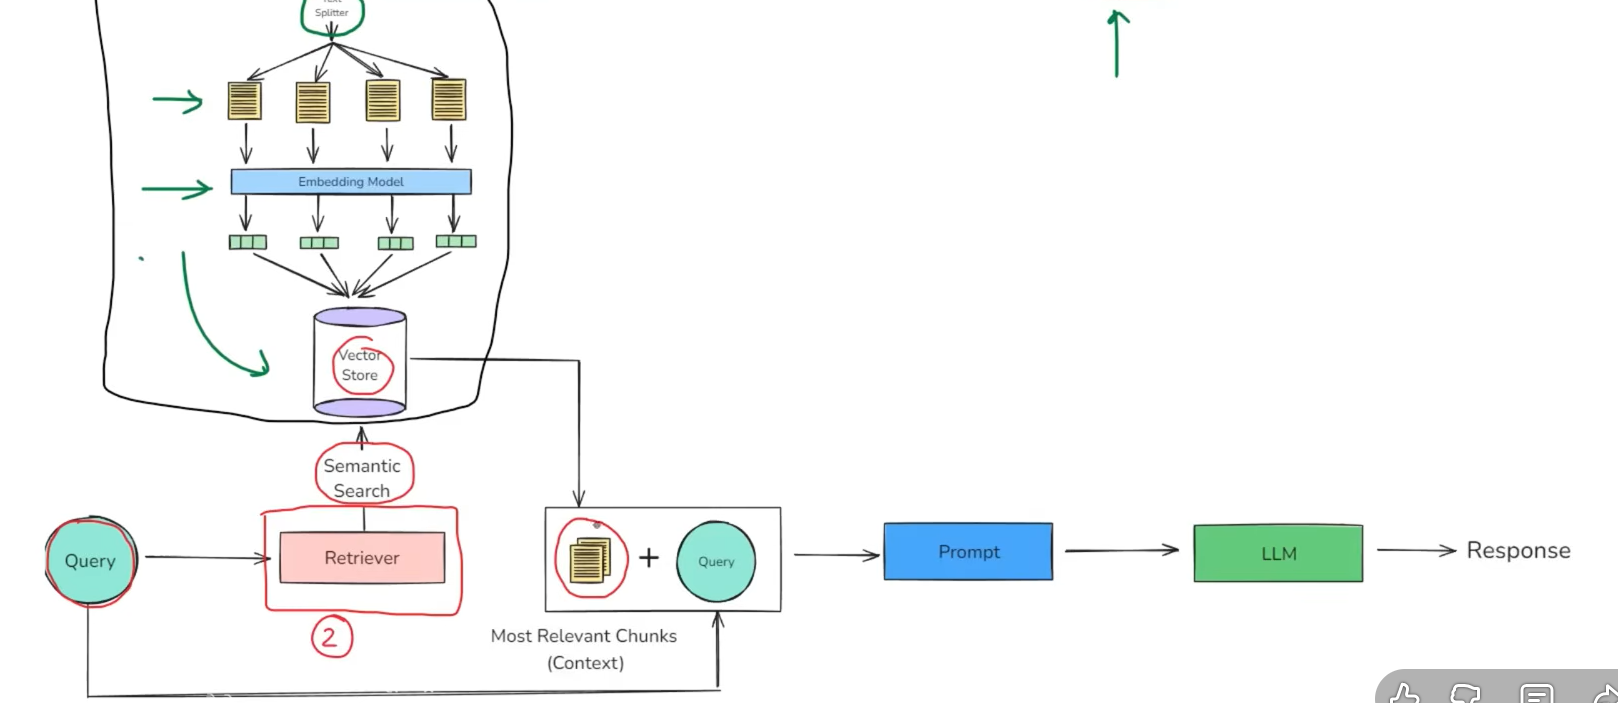

In [6]:
pip install youtube-transcript-api

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install -q langchain-text-splitters

import os
from dotenv import load_dotenv
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter

Note: you may need to restart the kernel to use updated packages.


c:\Users\Sikandar\miniconda3\envs\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

video_id = "yq_J2S8UBRc"

try:
    transcript = YouTubeTranscriptApi().fetch(video_id, languages=['en'])
    transcript_text = " ".join([t.text for t in transcript])
    print(transcript_text[:500])
except TranscriptsDisabled:
    print("Transcripts are disabled for this video.")

English Leap Podcast >> from Speak English with Claus. Hey English learners, welcome back to the English Leap Podcast. Your cozy place to learn easy English through real life conversations and work on your life at the same time. I'm Anna >> and I am Jake. Okay, before we say anything deep, I want to play a tiny game with you and with everyone listening. >> Ooh, a game already. I like this. All right. If you think about 2026 so far from 1 to 10, how is your life going right now? But wait, you can


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.create_documents([transcript_text])

In [4]:
chunks[10]

Document(metadata={}, page_content="stupid, that decision is what really hurts your life. >> So if you know you will fall short sometimes, you can plan how to respond before it happens. >> That takes us to the next part. If you want a comeback, dreams are not enough. >> Yeah, I love dreams. Vision boards, big plans, all of that. But dreams without structure are like clouds. Beautiful, but they don't move your life. >> You can dream the new you every night and still wake up as the old you every morning. >> Exactly. You need something more boring and more powerful. Goals and consistency. >> H So how do we make that practical for our listeners? >> One way is to anticipate your weak moments instead of pretending you are always strong. Anticipate means you expect something before it happens and you prepare for it. >> Right? For example, if you know that after work you were tired, anticipate that. Maybe do your English in the morning or do a smaller session in the evening. >> Or if you know 

In [5]:
embeddings = OpenAIEmbeddings(model= 'text-embedding-3-small')
vectore_store = FAISS.from_documents(chunks, embeddings)
vectore_store

In [6]:
vectore_store.index_to_docstore_id

{0: 'b1674c4d-428a-4e29-a819-7c55dc7dfba4',
 1: '71a589fe-f6b9-41a0-8081-054d94c580ac',
 2: 'a332c5aa-a2d3-48d2-b0be-899ada0a7dbf',
 3: 'e855d4ef-566d-41a8-9c16-7e2a447cfdd2',
 4: '011f3417-be99-4f26-befc-ea296eb9b10c',
 5: '739ee1b9-1a00-4376-898b-9f0ca1b51b15',
 6: 'cbf1f86e-f8df-4b27-a4cb-1949ac2a984c',
 7: '1dcfa380-c9c9-4a38-8223-709de14829ff',
 8: '191917fa-1db8-4452-bb92-598393d84113',
 9: 'c6b577f7-056a-4040-8adb-31d9b6e53b24',
 10: 'd695f6fe-a661-4d45-a371-e4d4dc7e698c',
 11: 'ef5350c4-0d02-418c-908e-d0fe1b75c3bd',
 12: '5e758a64-1739-423f-8cf2-5cb58e4a077c',
 13: '353c0318-fd66-4b51-92fa-87b71223a80d',
 14: '3cd4ce70-1566-4fb7-9c43-06d218a45e47',
 15: '1427609a-9859-46bc-9d3c-095cdb1987e5',
 16: '724dcfc1-7f11-413e-a115-88ab313e7452',
 17: 'd7aa07a9-7848-411e-8de0-32ad49c7c32b',
 18: 'ada77379-eee5-4889-b73d-028d97a16e16',
 19: 'ab593b37-fa46-4b83-9b2f-04340fe0d6d5',
 20: 'b5eaa9af-73e2-4368-8fc8-88a158870c1a',
 21: '716b2ff4-2662-416a-a9ef-bc4121953ed6',
 22: '1772ca12-f0d1-

In [8]:
vectore_store.get_by_ids(["ca9e3bc3-341e-4a0b-8f1c-a9b321d31e58"])

[Document(id='ca9e3bc3-341e-4a0b-8f1c-a9b321d31e58', metadata={}, page_content='with a better system. >> You can repeat fall short of. >> Fall short of. >> Take your time. Fall short of. >> Last one. claw your way back to something. >> To claw your way back means to return to a better place after a very bad time with a lot of effort and struggle. >> For example, after hitting rock bottom, she slowly clawed her way back to a healthier life. Or you can claw your way back to confidence, one small brave action at a time. >> Repeat. Claw your way back. Claw your way back >> slowly. Claw your way back. >> Good. That was our word tour for today. >> If you want, you can replay this word tour and shadow with us. Repeat with us until these words feel natural in your mouth. >> And remember, you do not need to use all 10 tomorrow. Even one or two words can already change how you talk about your life. Especially words like rise from the ashes and claw your way back. Those are not just English. They

In [10]:
retriever = vectore_store.as_retriever(
    search_type = 'similarity', 
    search_kwargs = {'k': 3}
)
retriever

VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000019D8DB79870>, search_kwargs={'k': 3})

In [11]:
retriever.invoke(
    "what is the best way of learning english"
)

[Document(id='e855d4ef-566d-41a8-9c16-7e2a447cfdd2', metadata={}, page_content='rock bottom, drifting into the wrong life, and slowly rising from the ashes. >> We will also look at those quiet everyday choices that look small, but secretly decide your number on that 1 to 10 scale. >> And yes, we will do all of this in English that you can understand. This is a B2 to early C1 level episode. >> So, the language will be richer and more natural, but we will still speak clearly, repeat important ideas, and explain our word tour vocabulary as we go. >> And if you\'re strong B1 or A2, you can still stay with us. Some parts will feel challenging, but that\'s how your brain grows. You can always listen again, and you\'ll catch more every time. Maybe right now you\'re on a bus or at your desk or washing dishes or lying in bed with your phone in your hand thinking, "I really do not want another copy paste year." >> And if that\'s you, this episode is for you. >> And before we go deeper, one small

In [12]:
llm = ChatOpenAI(model= 'gpt-3.5-turbo', temperature=0.9)
prompt = PromptTemplate(
    template = """
    Use the following retrieved chunks of text to answer the {question} with this {context}. If you don't know the answer, say you don't know.""",
    input_variables = ['question', 'context']
)

In [13]:
question = "what is the best way of learning english"
context = retriever.invoke(question)

In [14]:
context_text = '\n\n'.join([c.page_content for c in context])
context_text

'rock bottom, drifting into the wrong life, and slowly rising from the ashes. >> We will also look at those quiet everyday choices that look small, but secretly decide your number on that 1 to 10 scale. >> And yes, we will do all of this in English that you can understand. This is a B2 to early C1 level episode. >> So, the language will be richer and more natural, but we will still speak clearly, repeat important ideas, and explain our word tour vocabulary as we go. >> And if you\'re strong B1 or A2, you can still stay with us. Some parts will feel challenging, but that\'s how your brain grows. You can always listen again, and you\'ll catch more every time. Maybe right now you\'re on a bus or at your desk or washing dishes or lying in bed with your phone in your hand thinking, "I really do not want another copy paste year." >> And if that\'s you, this episode is for you. >> And before we go deeper, one small request. M if you enjoy learning and thinking with us, please like this episod

In [17]:
final_prompt = prompt.invoke({
    "question": question,
    "context": context_text
})
final_prompt

StringPromptValue(text='\n    Use the following retrieved chunks of text to answer the what is the best way of learning english with this rock bottom, drifting into the wrong life, and slowly rising from the ashes. >> We will also look at those quiet everyday choices that look small, but secretly decide your number on that 1 to 10 scale. >> And yes, we will do all of this in English that you can understand. This is a B2 to early C1 level episode. >> So, the language will be richer and more natural, but we will still speak clearly, repeat important ideas, and explain our word tour vocabulary as we go. >> And if you\'re strong B1 or A2, you can still stay with us. Some parts will feel challenging, but that\'s how your brain grows. You can always listen again, and you\'ll catch more every time. Maybe right now you\'re on a bus or at your desk or washing dishes or lying in bed with your phone in your hand thinking, "I really do not want another copy paste year." >> And if that\'s you, this

In [18]:
results = llm.invoke(final_prompt)
print(results)

content='The best way of learning English with this rock bottom, drifting into the wrong life, and slowly rising from the ashes is to make small, everyday choices that contribute to your progress on a 1 to 10 scale. It is important to set clear, achievable goals and to consistently work towards them, even when progress may feel slow or not glamorous. By making small, consistent efforts and staying committed to your learning journey, you can overcome obstacles and continue to grow and improve your English skills. Remember that every small action you take is part of your comeback story, and celebrating these small victories is essential for maintaining motivation and momentum in your learning journey.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 668, 'total_tokens': 797, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tok

In [19]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough, RunnableSequence, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

In [20]:
def format_docs(docs):
    return '\n\n'.join([d.page_content for d in docs])

In [21]:
parrallel_chain = RunnableParallel({
    "context": retriever | RunnableLambda(format_docs),
    "question": RunnablePassthrough()
})
parser = StrOutputParser()
final_chain = parrallel_chain | prompt | llm | parser

In [22]:
final_chain.invoke("what is the best way of learning english")

'The best way of learning English with this rock bottom, drifting into the wrong life, and slowly rising from the ashes is to make small, consistent, and intentional choices in your everyday life. Focus on setting small, clear goals for yourself, such as listening to a podcast multiple times a week or writing a few sentences daily. Embrace the quiet repetition and gradual progress, even when it may not feel dramatic. Avoid comparing yourself to others and stay focused on your own journey. Remember that every small action you take is a part of your comeback story, and continue to push yourself to grow and improve.'

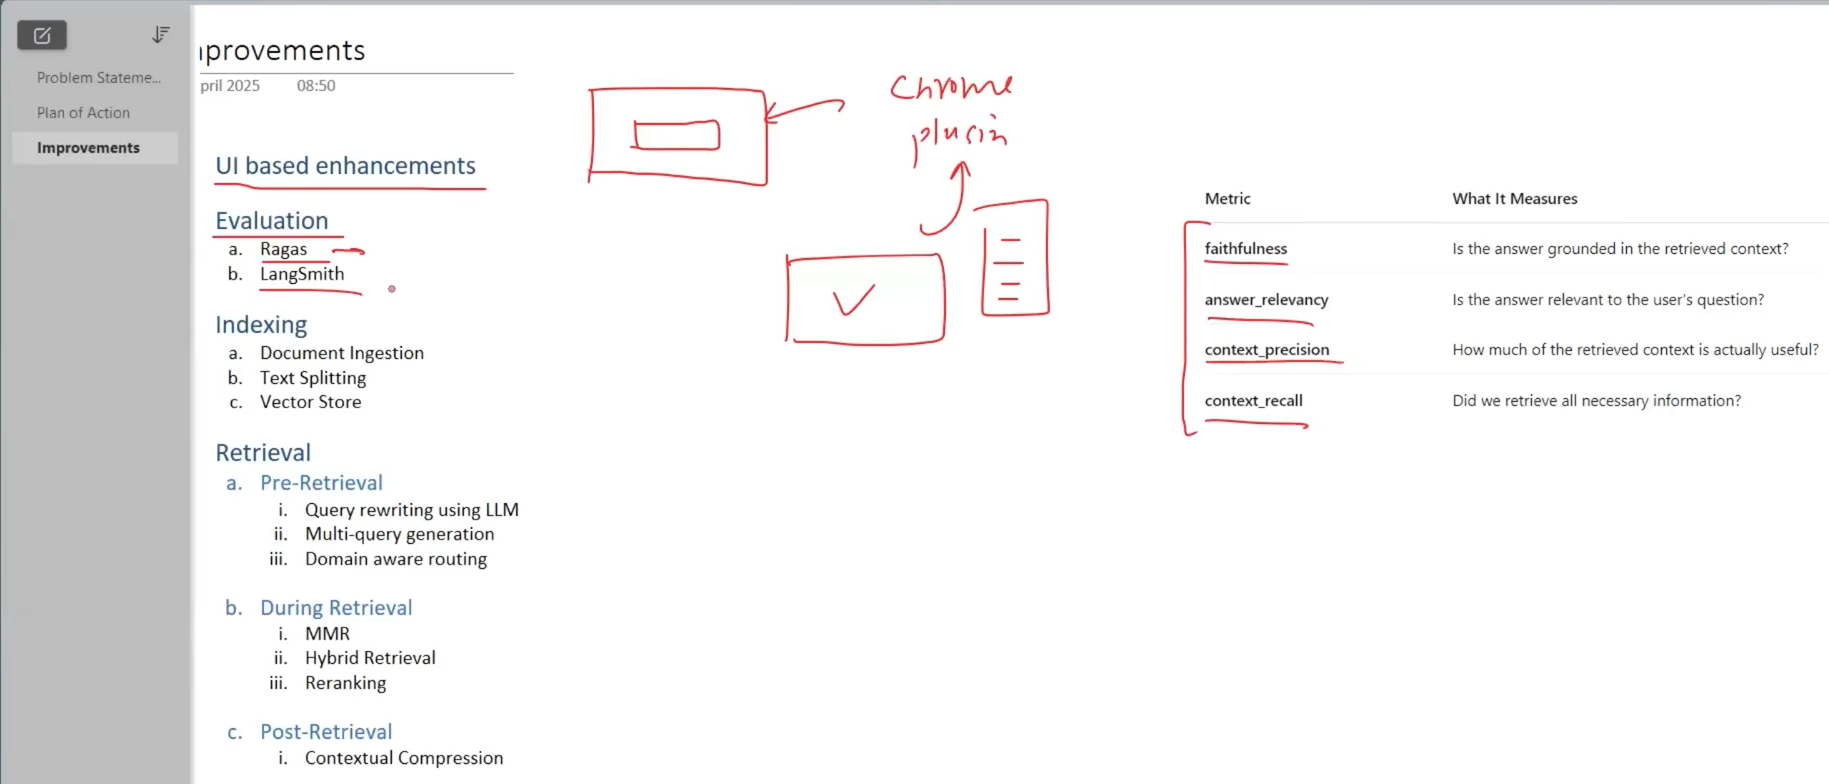
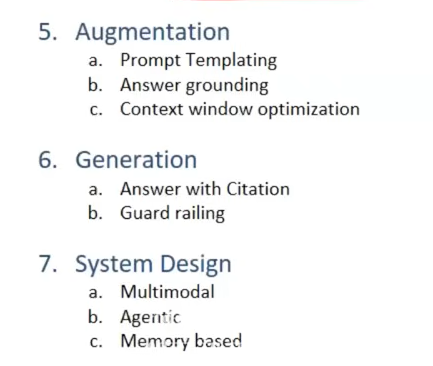